# Fruit and Vegetable Classification (PyTorch)

## Class activation heatmap (Grad-CAM)

This lab uses **PyTorch** and **torchvision** to classify **36** fruit and vegetable categories. An earlier version used TensorFlow/Keras; this notebook is **PyTorch-only**.

## Data layout

Place folders next to this notebook (or set `FRUIT_VEG_DATA_ROOT`):

- `train/<class_name>/*.jpg`
- `validation/<class_name>/*.jpg`
- `test/<class_name>/*.jpg`

Kaggle-style paths (`../input/fruit-and-vegetable-image-recognition/`) are also detected automatically.

## Environment

```bash
pip install -r requirements.txt
```

Then run Jupyter **from this directory** (the folder that contains `train/`, `validation/`, and `test/`).

![fruit vegetable](https://i.imgur.com/KUAcIQD.jpeg)


# Table of contents

1. [Loading and preprocessing](#1)  
2. [Data loaders (with augmentation)](#2)  
3. [Train MobileNetV2 transfer-learning model](#3)  
4. [Visualize training curves](#4)  
5. [Test-set accuracy and confusion matrix](#5)  
6. [Grad-CAM class activation maps](#6)

## Context

- **fruits**: banana, apple, pear, grapes, orange, kiwi, watermelon, pomegranate, pineapple, mango  
- **vegetables**: cucumber, carrot, capsicum, onion, potato, lemon, tomato, raddish, beetroot, cabbage, lettuce, spinach, soy bean, cauliflower, bell pepper, chilli pepper, turnip, corn, sweetcorn, sweet potato, paprika, jalepeño, ginger, garlic, peas, eggplant  

Typical counts: about **100 train / 10 validation / 10 test** images per class (your copy may differ).


# 1. Loading and preprocessing<a id='1'></a>

In [1]:
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import MobileNet_V2_Weights, mobilenet_v2

seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


def resolve_data_root() -> Path:
    cwd = Path.cwd().resolve()
    env = os.environ.get("FRUIT_VEG_DATA_ROOT")
    candidates: list[Path] = []
    if env:
        candidates.append(Path(env).expanduser().resolve())
    candidates.extend(
        [
            cwd,
            cwd / "fruit-and-vegetable-image-recognition",
            cwd.parent / "fruit-and-vegetable-image-recognition",
            Path("../input/fruit-and-vegetable-image-recognition").resolve(),
        ]
    )
    for p in candidates:
        if (p / "train").is_dir() and (p / "validation").is_dir() and (p / "test").is_dir():
            return p
    raise FileNotFoundError(
        "Could not locate dataset (need train/, validation/, test/). "
        "Open the notebook from the dataset folder or set FRUIT_VEG_DATA_ROOT."
    )


DATA_ROOT = resolve_data_root()
print("DATA_ROOT:", DATA_ROOT)

train_dir = DATA_ROOT / "train"
val_dir = DATA_ROOT / "validation"
test_dir = DATA_ROOT / "test"


def proc_img(paths: list[Path]) -> pd.DataFrame:
    labels = [p.parts[-2] for p in paths]
    df = pd.concat(
        [
            pd.Series([str(p) for p in paths], name="Filepath"),
            pd.Series(labels, name="Label"),
        ],
        axis=1,
    )
    return df.sample(frac=1, random_state=seed).reset_index(drop=True)


train_df = proc_img(sorted(train_dir.glob("**/*.jpg")))
val_df = proc_img(sorted(val_dir.glob("**/*.jpg")))
test_df = proc_img(sorted(test_dir.glob("**/*.jpg")))


DATA_ROOT: /Users/marcomacias/Projects/IARL/01_BWXT Data Science Workforce Training Pilot/Resources/Datasets and Labs/fruit&veg


In [2]:
print('-- Training set --\n')
print(f'Number of pictures: {train_df.shape[0]}\n')
print(f'Number of different labels: {train_df.Label.nunique()}\n')
print(f'Labels: {sorted(train_df.Label.unique())}')


-- Training set --

Number of pictures: 2780

Number of different labels: 36

Labels: ['apple', 'banana', 'beetroot', 'bell pepper', 'cabbage', 'capsicum', 'carrot', 'cauliflower', 'chilli pepper', 'corn', 'cucumber', 'eggplant', 'garlic', 'ginger', 'grapes', 'jalepeno', 'kiwi', 'lemon', 'lettuce', 'mango', 'onion', 'orange', 'paprika', 'pear', 'peas', 'pineapple', 'pomegranate', 'potato', 'raddish', 'soy beans', 'spinach', 'sweetcorn', 'sweetpotato', 'tomato', 'turnip', 'watermelon']


In [3]:
train_df.head()


,Filepath,Label
0,/Users/marcomacias/Projects/IARL/01_BWXT Data ...,sweetpotato
1,/Users/marcomacias/Projects/IARL/01_BWXT Data ...,cucumber
2,/Users/marcomacias/Projects/IARL/01_BWXT Data ...,spinach
3,/Users/marcomacias/Projects/IARL/01_BWXT Data ...,carrot
4,/Users/marcomacias/Projects/IARL/01_BWXT Data ...,watermelon


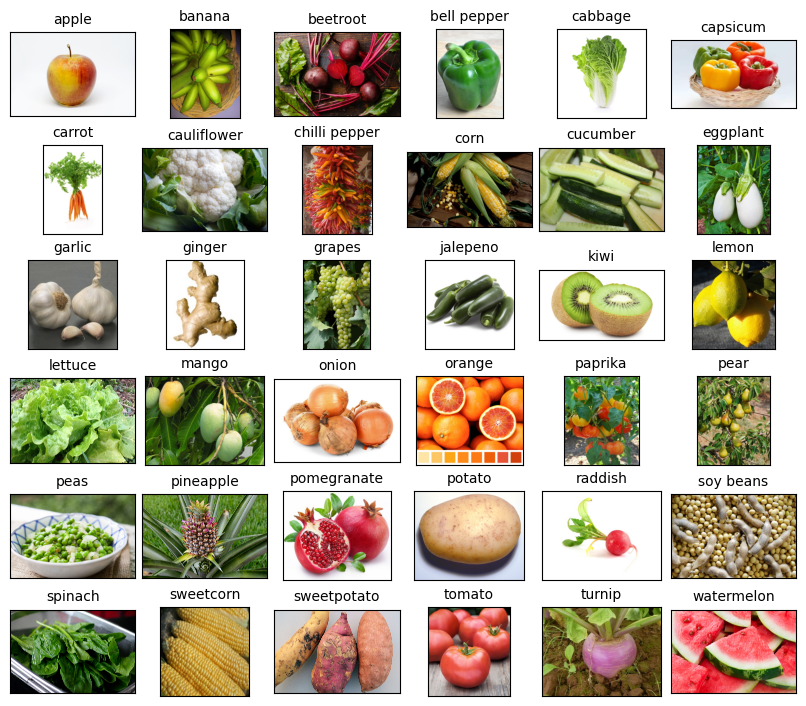

In [4]:
labels_sorted = sorted(train_df.Label.unique())
df_unique = (
    train_df.drop_duplicates(subset=['Label']).set_index('Label').loc[labels_sorted].reset_index()
)

fig, axes = plt.subplots(nrows=6, ncols=6, figsize=(8, 7), subplot_kw={'xticks': [], 'yticks': []})
for i, ax in enumerate(axes.flat):
    if i < len(df_unique):
        ax.imshow(np.asarray(Image.open(df_unique.Filepath.iloc[i]).convert('RGB')))
        ax.set_title(df_unique.Label.iloc[i], fontsize=10)
plt.tight_layout(pad=0.5)
plt.show()


# 2. Data loaders (with augmentation)<a id='2'></a>

In [5]:
weights_enum = MobileNet_V2_Weights.IMAGENET1K_V1
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(30),
        transforms.ColorJitter(0.15, 0.15, 0.15, 0.05),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)
eval_transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
)

train_ds = ImageFolder(str(train_dir), transform=train_transform)
val_ds = ImageFolder(str(val_dir), transform=eval_transform)
test_ds = ImageFolder(str(test_dir), transform=eval_transform)

assert train_ds.classes == val_ds.classes == test_ds.classes

batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

class_names = train_ds.classes
idx_to_class = {i: c for i, c in enumerate(class_names)}
num_classes = len(class_names)
print('num_classes:', num_classes)


num_classes: 36


# 3. Train MobileNetV2 transfer-learning model<a id='3'></a>

In [6]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('device:', device)

model = mobilenet_v2(weights=weights_enum)
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(in_features, 128),
    nn.ReLU(inplace=True),
    nn.Linear(128, num_classes),
)
for p in model.features.parameters():
    p.requires_grad = False

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad], lr=1e-3)


def run_epoch(loader, train_mode: bool):
    model.train(train_mode)
    total_loss = 0.0
    correct = 0
    total = 0
    grad_ctx = torch.enable_grad() if train_mode else torch.no_grad()
    with grad_ctx:
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)
            if train_mode:
                optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, targets)
            if train_mode:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            correct += (logits.argmax(dim=1) == targets).sum().item()
            total += images.size(0)
    return total_loss / max(total, 1), correct / max(total, 1)


max_epochs = 5
patience = 2
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val = float('inf')
best_state = None
bad_epochs = 0

for epoch in range(1, max_epochs + 1):
    tr_loss, tr_acc = run_epoch(train_loader, True)
    va_loss, va_acc = run_epoch(val_loader, False)
    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(va_loss)
    history['val_acc'].append(va_acc)
    print(
        f'Epoch {epoch}/{max_epochs}  train_loss={tr_loss:.4f} acc={tr_acc:.4f}  '
        f'val_loss={va_loss:.4f} acc={va_acc:.4f}'
    )
    if va_loss < best_val - 1e-6:
        best_val = va_loss
        best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            print(f'Early stopping: no val_loss improvement for {patience} epochs.')
            break

if best_state is not None:
    model.load_state_dict(best_state)

print('Restored best val_loss:', best_val)


device: mps


/Users/marcomacias/Projects/IARL/.venv/lib/python3.13/site-packages/PIL/Image.py:1137: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/5  train_loss=2.6554 acc=0.3252  val_loss=1.1407 acc=0.7493
Epoch 2/5  train_loss=1.4818 acc=0.6010  val_loss=0.7662 acc=0.7692
Epoch 3/5  train_loss=1.2199 acc=0.6360  val_loss=0.5744 acc=0.8205
Epoch 4/5  train_loss=1.0777 acc=0.6751  val_loss=0.5152 acc=0.8575
Epoch 5/5  train_loss=1.0304 acc=0.6851  val_loss=0.4776 acc=0.8348
Restored best val_loss: 0.47759193063121913


# 4. Visualize training curves<a id='4'></a>

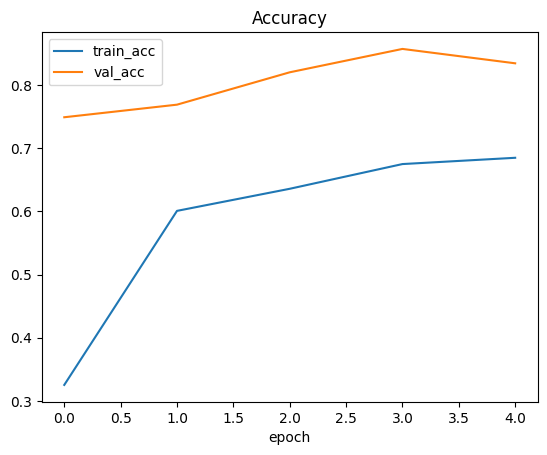

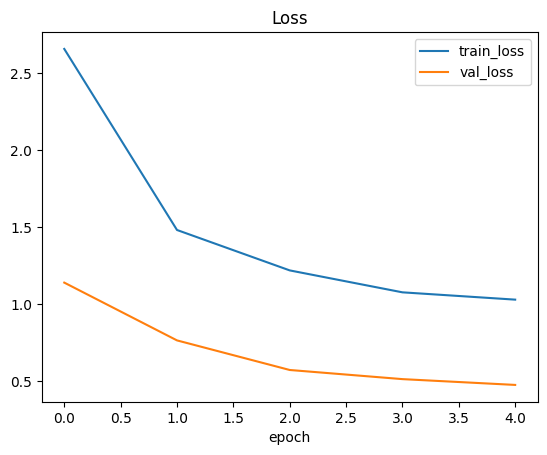

In [7]:
hist = pd.DataFrame(history)
hist[['train_acc', 'val_acc']].plot(title='Accuracy')
plt.xlabel('epoch')
plt.show()

hist[['train_loss', 'val_loss']].plot(title='Loss')
plt.xlabel('epoch')
plt.show()


# 5. Test-set accuracy and confusion matrix<a id='5'></a>

In [8]:
model.eval()
all_preds: list[np.ndarray] = []
all_targets: list[np.ndarray] = []
with torch.no_grad():
    for images, targets in test_loader:
        images = images.to(device)
        logits = model(images)
        all_preds.append(logits.argmax(dim=1).cpu().numpy())
        all_targets.append(targets.numpy())

pred_idx = np.concatenate(all_preds)
true_idx = np.concatenate(all_targets)
pred_labels = [idx_to_class[i] for i in pred_idx]
true_labels = [idx_to_class[i] for i in true_idx]

acc = accuracy_score(true_labels, pred_labels)
print(f'Accuracy on the test set: {100 * acc:.2f}%')


Accuracy on the test set: 83.29%


In [ ]:
labels_ordered = sorted(set(true_labels))
cm = confusion_matrix(true_labels, pred_labels, labels=labels_ordered, normalize='true')
plt.figure(figsize=(15, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt='.2f',
    xticklabels=labels_ordered,
    yticklabels=labels_ordered,
)
plt.title('Normalized Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()


In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15), subplot_kw={'xticks': [], 'yticks': []})
paths = test_df.Filepath.tolist()
for i, ax in enumerate(axes.flat):
    p = paths[i]
    ax.imshow(np.asarray(Image.open(p).convert('RGB')))
    ax.set_title(f'True: {test_df.Label.iloc[i]}\nPredicted: {pred_labels[i]}')
plt.tight_layout()
plt.show()


## 6. Grad-CAM class activation heatmaps<a id='6'></a>

In [ ]:
def numpy_to_tensor(img_rgb: np.ndarray) -> torch.Tensor:
    # HWC uint8 / float RGB -> NCHW normalized tensor
    x = torch.from_numpy(img_rgb.astype('float32'))
    if x.max() > 1.0:
        x = x / 255.0
    if x.ndim == 2:
        x = x.unsqueeze(-1).repeat(1, 1, 3)
    x = x.permute(2, 0, 1)
    for t, m, s in zip(x, IMAGENET_MEAN, IMAGENET_STD):
        t.sub_(m).div_(s)
    return x.unsqueeze(0)


def preprocess_image_path(img_path: str | Path) -> torch.Tensor:
    img = Image.open(img_path).convert('RGB').resize((224, 224))
    return numpy_to_tensor(np.asarray(img)).to(device)


def grad_cam_heatmap(model_, input_tensor: torch.Tensor, target_class: int | None):
    # Grad-CAM: last conv block in torchvision MobileNetV2 is model.features[18]
    # Enable grad on input so gradients flow into frozen backbone feature maps.
    input_tensor = input_tensor.clone().detach().requires_grad_(True)
    model_.eval()
    acts: list[torch.Tensor] = []

    def hook(_m, _inp, out):
        out.retain_grad()
        acts.append(out)

    h = model_.features[18].register_forward_hook(hook)
    logits = model_(input_tensor)
    if target_class is None:
        target_class = int(logits.argmax(dim=1).item())
    model_.zero_grad(set_to_none=True)
    logits[0, target_class].backward()
    h.remove()
    a = acts[0]
    g = a.grad
    w = g.mean(dim=(2, 3), keepdim=True)
    cam = (w * a).sum(dim=1).squeeze(0)
    cam = torch.relu(cam).detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam


def superimpose_cam(img_path: str | Path, heatmap: np.ndarray, alpha: float = 0.4) -> np.ndarray:
    img = Image.open(img_path).convert('RGB')
    w, h = img.size
    hm_img = Image.fromarray((heatmap * 255).astype(np.uint8)).resize((w, h), Image.Resampling.BILINEAR)
    hm = np.asarray(hm_img).astype(np.float32) / 255.0
    colored = plt.cm.jet(hm)[:, :, :3] * 255.0
    base = np.asarray(img).astype(np.float32)
    out = alpha * colored + (1.0 - alpha) * base
    return np.clip(out, 0, 255).astype(np.uint8)


print('Grad-CAM on first nine test images')
fig, axes = plt.subplots(3, 3, figsize=(15, 15), subplot_kw={'xticks': [], 'yticks': []})
for i, ax in enumerate(axes.flat):
    path = test_df.Filepath.iloc[i]
    x = preprocess_image_path(path)
    pred_class = int(model(x).argmax(dim=1).item())
    hm = grad_cam_heatmap(model, x, pred_class)
    overlay = superimpose_cam(path, hm)
    ax.imshow(overlay)
    ax.set_title(f"True: {test_df.Label.iloc[i]}\nPredicted: {pred_labels[i]}")
plt.tight_layout()
plt.show()
